# 06_evaluate

Evaluates the trained TFT checkpoint and optionally resumes training.

- Load checkpoint from `/Volumes/precursor/models/artifacts/tft_checkpoint.ckpt`
- Run inference on the test set (2024-01-01 onward)
- Log preliminary metrics to MLflow
- Optionally resume training from the checkpoint

In [0]:
%pip install xgboost scikit-learn pytorch-forecasting protobuf==5.29.3 "numpy<2.0" lightning pytorch-lightning -q
%pip install torch --index-url https://download.pytorch.org/whl/cpu -q


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import mlflow
import mlflow.pytorch
import pandas as pd
import numpy as np
import logging
from datetime import datetime

import torch
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import CrossEntropy
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report,
)

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("precursor.evaluate")

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks-uc")

TRAIN_END    = "2023-12-31"
TEST_START   = "2024-01-01"
MODEL_VOLUME = "/Volumes/precursor/models/artifacts"
CKPT_PATH    = f"{MODEL_VOLUME}/tft_checkpoint.ckpt"

FEATURE_COLS = [
    "return_1d", "return_5d", "return_21d", "return_63d",
    "volatility_21d", "volatility_63d",
    "volume_zscore_21d",
    "price_vs_52w_high", "price_vs_52w_low",
    "price_vs_sma20", "price_vs_sma50", "price_vs_sma200",
    "rsi_14", "macd", "macd_signal", "macd_histogram",
    "bb_width", "bb_position",
    "obv_5d_sum", "obv_21d_sum",
    "atr_pct",
    "fed_rate_delta_21d", "fed_rate_delta_63d",
    "yield_curve_level", "yield_curve_change_21d",
    "vix_level", "vix_zscore_63d",
    "inflation_mom", "unemployment_delta_63d",
    "m2_growth_63d", "macro_regime",
    "insider_filings_7d", "insider_filings_30d",
    "insider_filings_90d",
    "insider_activity_spike",
    "days_since_last_filing",
]
TARGET_COL = "target_1d"

TIME_VARYING_KNOWN = [
    "fed_rate_delta_21d", "fed_rate_delta_63d",
    "yield_curve_level", "yield_curve_change_21d",
    "vix_level", "vix_zscore_63d",
    "inflation_mom", "unemployment_delta_63d",
    "m2_growth_63d", "macro_regime",
]
TIME_VARYING_UNKNOWN = [
    "return_1d", "return_5d", "return_21d", "return_63d",
    "volatility_21d", "volume_zscore_21d",
    "rsi_14", "macd", "bb_position", "atr_pct",
    "insider_filings_7d", "insider_filings_30d",
    "insider_activity_spike",
]

logger.info("Evaluate notebook initialised. Checkpoint: %s", CKPT_PATH)

/databricks/python/lib/python3.11/site-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


## Cell 3 — Load and prepare data

In [0]:
def load_and_prepare() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    cols = ["ticker", "date", "sector"] + FEATURE_COLS + [TARGET_COL]

    df = (
        spark.table("precursor.gold.features")
        .filter(f"{TARGET_COL} IS NOT NULL")
        .select(*cols)
        .orderBy("date")
        .toPandas()
    )
    df["date"] = pd.to_datetime(df["date"])

    memory_cutoff = "2022-01-01"
    if len(df) > 500_000:
        df = df[df["date"].dt.strftime("%Y-%m-%d") >= memory_cutoff].copy()

    df = df.sort_values(["ticker", "date"]).copy()
    df["time_idx"]    = df.groupby("ticker").cumcount()
    df["ticker"]      = df["ticker"].astype(str)
    df["sector"]      = df["sector"].astype(str)
    df["macro_regime"] = df["macro_regime"].astype(float)
    df[FEATURE_COLS]  = df[FEATURE_COLS].fillna(0.0)
    df[TARGET_COL]    = df[TARGET_COL].astype(int)

    train_df = df[df["date"].dt.strftime("%Y-%m-%d") <= TRAIN_END].copy()
    val_df   = df[df["date"].dt.strftime("%Y-%m-%d") >= TEST_START].copy()

    logger.info("train_df: %d rows, val_df: %d rows", len(train_df), len(val_df))
    return df, train_df, val_df


df, train_df, val_df = load_and_prepare()

## Cell 4 — Rebuild datasets (must match 05_train exactly)

In [0]:
training_dataset = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target=TARGET_COL,
    group_ids=["ticker"],
    max_encoder_length=63,
    max_prediction_length=1,
    static_categoricals=["ticker", "sector"],
    categorical_encoders={
        "ticker": NaNLabelEncoder(add_nan=True),
        "sector": NaNLabelEncoder(add_nan=True),
    },
    time_varying_known_reals=TIME_VARYING_KNOWN,
    time_varying_unknown_reals=TIME_VARYING_UNKNOWN,
    target_normalizer=None,
)

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, val_df, predict=True, stop_randomization=True,
)

val_dataloader = validation_dataset.to_dataloader(
    train=False, batch_size=128, num_workers=0,
)

logger.info("Datasets rebuilt.")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-468355ba-699e-42d6-8277-be9334b5859a/lib/python3.11/site-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 10 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__ticker': 'BLDR'}, {'__group_id__ticker': 'GPS'}, {'__group_id__ticker': 'HUBB'}, {'__group_id__ticker': 'INFO'}, {'__group_id__ticker': 'JBL'}, {'__group_id__ticker': 'LULU'}, {'__group_id__ticker': 'PBCT'}, {'__group_id__ticker': 'UBER'}, {'__group_id__ticker': 'VLTO'}, {'__group_id__ticker': 'XLNX'}]
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-468355ba-699e-42d6-8277-be9334b5859a/lib/python3.11/site-packages/pytorch_forecasting/data/encoders.py:402: UserWarning: Found 43 unknown classes which were set to NaN
  warnings.warn(
/

## Cell 5 — Load checkpoint and evaluate

In [0]:
import os
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"

tft = TemporalFusionTransformer.load_from_checkpoint(CKPT_PATH)
tft.eval()
logger.info("Checkpoint loaded: %s", CKPT_PATH)
logger.info("TFT parameters: %d", sum(p.numel() for p in tft.parameters()))

with mlflow.start_run(run_name="tft_evaluation"):
    mlflow.log_param("checkpoint", CKPT_PATH)

    predict_output = tft.predict(val_dataloader, mode="raw", return_x=True)
    raw_preds = predict_output[0]
    x         = predict_output[1]

    preds_prob   = raw_preds["prediction"].squeeze(-2)[:, 1].numpy()
    preds_binary = (preds_prob > 0.5).astype(int)
    y_val        = val_df[TARGET_COL].values[-len(preds_binary):]

    metrics = {
        "accuracy": float(accuracy_score(y_val, preds_binary)),
        "auc":      float(roc_auc_score(y_val, preds_prob)),
    }
    mlflow.log_metrics(metrics)
    logger.info("Preliminary metrics (checkpoint eval): %s", metrics)
    print(classification_report(y_val, preds_binary))

    try:
        interpretation = tft.interpret_output(raw_preds, reduction="sum")
        mlflow.log_dict(
            {k: v.tolist() for k, v in interpretation.items() if hasattr(v, "tolist")},
            "tft_variable_importance.json",
        )
        logger.info("Variable importance logged.")
    except Exception as e:
        logger.warning("Variable importance failed: %s", e)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-468355ba-699e-42d6-8277-be9334b5859a/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/local_disk0/.ephemeral_nfs/envs/pythonEnv-468355ba-699e-42d6-8277-be9334b5859a/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try insta

              precision    recall  f1-score   support

           0       0.50      0.98      0.66       264
           1       0.60      0.02      0.04       266

    accuracy                           0.50       530
   macro avg       0.55      0.50      0.35       530
weighted avg       0.55      0.50      0.35       530



## Cell 6 — Variable importance plot

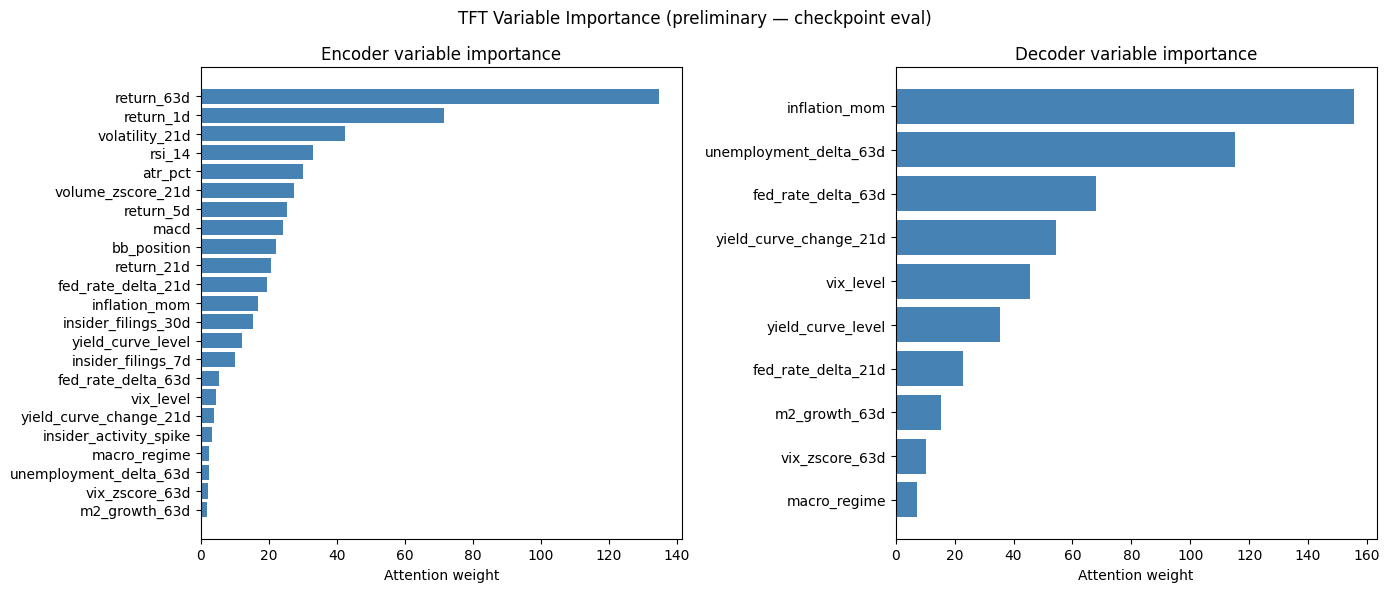

In [0]:
import matplotlib.pyplot as plt

interpretation = tft.interpret_output(raw_preds, reduction="sum")

# Encoder sees all real variables: unknown + known
ENCODER_NAMES = TIME_VARYING_UNKNOWN + TIME_VARYING_KNOWN
DECODER_NAMES = TIME_VARYING_KNOWN

try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, key, title, names in [
        (axes[0], "encoder_variables", "Encoder variable importance", ENCODER_NAMES),
        (axes[1], "decoder_variables", "Decoder variable importance", DECODER_NAMES),
    ]:
        vals  = interpretation[key].numpy().flatten()
        names = names[:len(vals)]
        order = np.argsort(vals)[::-1]
        ax.barh([names[i] for i in order], vals[order], color="steelblue")
        ax.set_title(title)
        ax.set_xlabel("Attention weight")
        ax.invert_yaxis()

    plt.suptitle("TFT Variable Importance (preliminary — checkpoint eval)", fontsize=12)
    plt.tight_layout()
    plt.savefig("/tmp/tft_variable_importance.png", dpi=120)
    plt.show()
    logger.info("Variable importance plot saved.")
except Exception as e:
    logger.warning("Plot failed: %s", e)

## Cell 7 — Resume training (optional)

Run this cell to continue training from the checkpoint. Adjust `max_epochs` to set the new total epoch target (not additional epochs — Lightning counts from where it left off).

In [0]:
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

RESUME_MAX_EPOCHS = 10  # total epochs including already-completed ones

train_dataloader = training_dataset.to_dataloader(
    train=True, batch_size=128, num_workers=0,
)

# Rebuild model from dataset so architecture matches checkpoint
tft_resume = TemporalFusionTransformer.from_dataset(
    training_dataset,
    loss=CrossEntropy(),
    learning_rate=0.001,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    output_size=2,
    log_interval=10,
    reduce_on_plateau_patience=3,
)

trainer = Trainer(
    max_epochs=RESUME_MAX_EPOCHS,
    accelerator="cpu",
    enable_progress_bar=True,
    gradient_clip_val=0.1,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, mode="min"),
        ModelCheckpoint(
            dirpath=MODEL_VOLUME,
            filename="tft_checkpoint",
            monitor="val_loss",
            save_top_k=1,
        ),
    ],
)

with mlflow.start_run(run_name="tft_resumed"):
    trainer.fit(
        tft_resume,
        train_dataloader,
        val_dataloader,
        ckpt_path=CKPT_PATH,  # resumes from saved epoch
    )
    logger.info("Resumed training complete.")

In [0]:
import pickle
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

XGB_PATH = f"{MODEL_VOLUME}/xgb_baseline.pkl"
assert os.path.exists(XGB_PATH), f"XGBoost model not found: {XGB_PATH}"

with open(XGB_PATH, "rb") as f:
    xgb_model = pickle.load(f)

X_val = val_df[FEATURE_COLS]
y_val_xgb = val_df[TARGET_COL].values

xgb_preds      = xgb_model.predict(X_val)
xgb_preds_prob = xgb_model.predict_proba(X_val)[:, 1]

xgb_metrics = {
    "accuracy":  float(accuracy_score(y_val_xgb, xgb_preds)),
    "auc":       float(roc_auc_score(y_val_xgb, xgb_preds_prob)),
    "precision": float(precision_score(y_val_xgb, xgb_preds, zero_division=0)),
    "recall":    float(recall_score(y_val_xgb, xgb_preds, zero_division=0)),
    "f1":        float(f1_score(y_val_xgb, xgb_preds, zero_division=0)),
}
logger.info("XGBoost metrics: %s", xgb_metrics)
print(classification_report(y_val_xgb, xgb_preds))

              precision    recall  f1-score   support

           0       0.49      0.58      0.53    139392
           1       0.53      0.43      0.47    151104

    accuracy                           0.50    290496
   macro avg       0.51      0.51      0.50    290496
weighted avg       0.51      0.50      0.50    290496



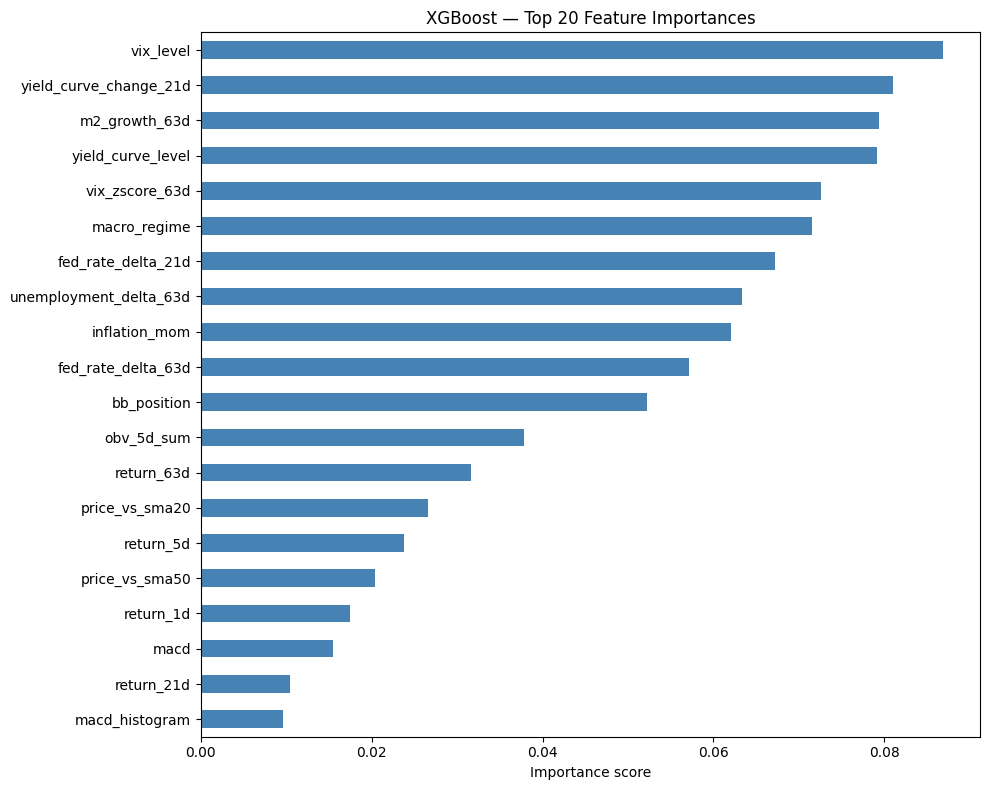

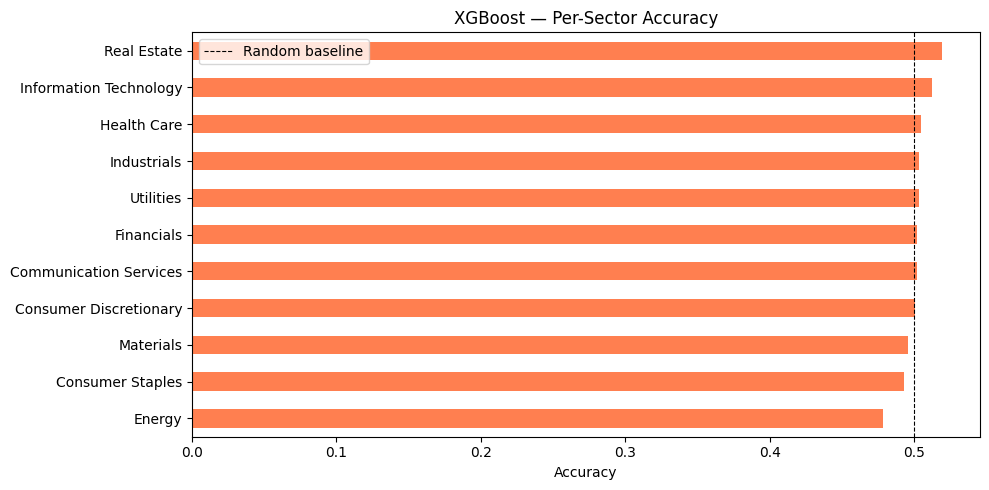

In [0]:
importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(20).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("XGBoost — Top 20 Feature Importances")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("/tmp/xgb_feature_importance.png", dpi=120)
plt.show()

# Per-sector accuracy
sector_acc = {}
val_df_copy = val_df.copy()
val_df_copy["_pred"] = xgb_preds
for sector, grp in val_df_copy.groupby("sector"):
    acc = accuracy_score(grp[TARGET_COL], grp["_pred"])
    sector_acc[sector] = acc

sector_series = pd.Series(sector_acc).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sector_series.sort_values().plot.barh(ax=ax, color="coral")
ax.set_title("XGBoost — Per-Sector Accuracy")
ax.set_xlabel("Accuracy")
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8, label="Random baseline")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/xgb_sector_accuracy.png", dpi=120)
plt.show()

In [0]:
import os
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"

tft = TemporalFusionTransformer.load_from_checkpoint(CKPT_PATH)
tft.eval()
logger.info("Checkpoint loaded: %s", CKPT_PATH)
logger.info("TFT parameters: %d", sum(p.numel() for p in tft.parameters()))

with mlflow.start_run(run_name="tft_evaluation"):
    mlflow.log_param("checkpoint", CKPT_PATH)

    predict_output = tft.predict(val_dataloader, mode="raw", return_x=True)
    raw_preds = predict_output[0]
    x         = predict_output[1]

    preds_prob   = raw_preds["prediction"].squeeze(-2)[:, 1].numpy()
    preds_binary = (preds_prob > 0.5).astype(int)
    y_val        = val_df[TARGET_COL].values[-len(preds_binary):]

    metrics = {
        "accuracy": float(accuracy_score(y_val, preds_binary)),
        "auc":      float(roc_auc_score(y_val, preds_prob)),
    }
    mlflow.log_metrics(metrics)
    logger.info("Preliminary metrics (checkpoint eval): %s", metrics)
    print(classification_report(y_val, preds_binary))

    try:
        interpretation = tft.interpret_output(raw_preds, reduction="sum")
        mlflow.log_dict(
            {k: v.tolist() for k, v in interpretation.items() if hasattr(v, "tolist")},
            "tft_variable_importance.json",
        )
        logger.info("Variable importance logged.")
    except Exception as e:
        logger.warning("Variable importance failed: %s", e)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-468355ba-699e-42d6-8277-be9334b5859a/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/local_disk0/.ephemeral_nfs/envs/pythonEnv-468355ba-699e-42d6-8277-be9334b5859a/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try insta

              precision    recall  f1-score   support

           0       0.50      0.98      0.66       264
           1       0.60      0.02      0.04       266

    accuracy                           0.50       530
   macro avg       0.55      0.50      0.35       530
weighted avg       0.55      0.50      0.35       530



In [0]:
tft_metrics = {
    "accuracy":  float(accuracy_score(y_val, preds_binary)),
    "auc":       float(roc_auc_score(y_val, preds_prob)),
    "precision": float(precision_score(y_val, preds_binary, zero_division=0)),
    "recall":    float(recall_score(y_val, preds_binary, zero_division=0)),
    "f1":        float(f1_score(y_val, preds_binary, zero_division=0)),
}

metrics_order = ["accuracy", "auc", "precision", "recall", "f1"]
labels        = ["Accuracy", "AUC-ROC", "Precision", "Recall", "F1"]

xgb_vals = [xgb_metrics[m] for m in metrics_order]
tft_vals  = [tft_metrics[m] for m in metrics_order]

print("=" * 52)
print("  MODEL COMPARISON — TEST SET (preliminary TFT)")
print("=" * 52)
print(f"  {'Metric':<20} {'XGBoost':>12} {'TFT':>12}")
print("-" * 52)
for label, xv, tv in zip(labels, xgb_vals, tft_vals):
    print(f"  {label:<20} {xv:>12.4f} {tv:>12.4f}")
print("=" * 52)

winner = "TFT" if tft_metrics["auc"] > xgb_metrics["auc"] else "XGBoost"
print(f"  Leading model (AUC): {winner}")
print("=" * 52)

  MODEL COMPARISON — TEST SET (preliminary TFT)
  Metric                    XGBoost          TFT
----------------------------------------------------
  Accuracy                   0.5028       0.5019
  AUC-ROC                    0.5027       0.5128
  Precision                  0.5272       0.6000
  Recall                     0.4279       0.0226
  F1                         0.4724       0.0435
  Leading model (AUC): TFT


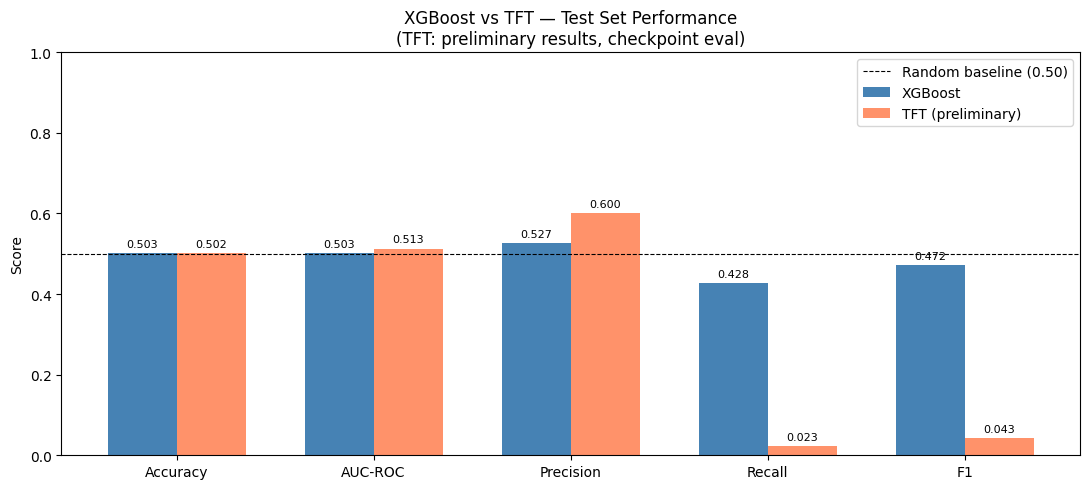

In [0]:
x_pos = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x_pos - width/2, xgb_vals, width, label="XGBoost", color="steelblue")
bars2 = ax.bar(x_pos + width/2, tft_vals,  width, label="TFT (preliminary)", color="coral", alpha=0.85)

ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="Random baseline (0.50)")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel("Score")
ax.set_title("XGBoost vs TFT — Test Set Performance\n(TFT: preliminary results, checkpoint eval)")
ax.set_ylim(0, 1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("/tmp/model_comparison.png", dpi=120)
plt.show()